# Análisis Exploratorio de Datos (EDA) - Incontinencia Urinaria
**Autora:** Isabel (Scrum Master - Equipo 3)
**Fecha:** 16/03/2026

## 1. Carga y Validación de Datos
En este primer paso, conectamos con el dataset original proporcionado por Iris en la carpeta `data/raw/`. 
Nuestro objetivo es verificar que las dimensiones coincidan con la documentación técnica (9.074 registros).

In [2]:
import pandas as pd
import os

# Definimos la ruta relativa al archivo CSV que subió Iris
# Estamos en notebooks/modeling/, así que subimos dos niveles para llegar a data/raw/
ruta_datos = os.path.join("..", "..", "data", "raw", "nhanes_ui_women.csv")

try:
    df = pd.read_csv(ruta_datos)
    print("✅ ¡Datos cargados con éxito!")
    print(f"📊 Dimensiones del dataset: {df.shape[0]} filas y {df.shape[1]} columnas")
    
    # Mostramos las primeras 5 filas para verificar el contenido
    display(df.head())
except FileNotFoundError:
    print("❌ Error: No se encuentra el archivo en la ruta especificada.")
    print(f"Buscando en: {os.path.abspath(ruta_datos)}")
except Exception as e:
    print(f"❌ Ha ocurrido un error inesperado: {e}")

✅ ¡Datos cargados con éxito!
📊 Dimensiones del dataset: 9074 filas y 27 columnas


,id_participante,ciclo_nhanes,peso_encuesta,edad_anios,etnia,pais_nacimiento,imc,dx_hipertension,medicacion_hta_cicloP,medicacion_hta_cicloL,...,ui_cantidad,ui_esfuerzo_presente,ui_esfuerzo_frecuencia,ui_urgencia_presente,ui_urgencia_frecuencia,ui_otro_tipo_presente,ui_molestia_percibida,ui_impacto_actividades,target_tiene_ui,target_tipo_ui
0,109266.0,2017-March2020,NaN,29.0,5.0,2.0,37.8,2.0,NaN,NaN,...,NaN,2.0,NaN,2.0,NaN,2.0,NaN,NaN,0,none
1,109267.0,2017-March2020,NaN,21.0,2.0,2.0,NaN,2.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,none
2,109284.0,2017-March2020,NaN,44.0,1.0,2.0,39.1,2.0,NaN,NaN,...,1.0,1.0,1.0,2.0,NaN,2.0,2.0,2.0,1,stress
3,109286.0,2017-March2020,NaN,33.0,5.0,2.0,28.9,2.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,none
4,109290.0,2017-March2020,NaN,68.0,4.0,1.0,28.1,1.0,1.0,NaN,...,2.0,2.0,NaN,1.0,1.0,2.0,2.0,1.0,1,urge


In [3]:
# Inspección de tipos de datos y valores nulos oficiales de Pandas
print("📋 Información general del DataFrame:")
display(df.info())

print("\n🔍 Recuento de valores nulos directos (NaN):")
print(df.isnull().sum())

📋 Información general del DataFrame:
<class 'pandas.DataFrame'>
RangeIndex: 9074 entries, 0 to 9073
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_participante            9074 non-null   float64
 1   ciclo_nhanes               9074 non-null   str    
 2   peso_encuesta              4321 non-null   float64
 3   edad_anios                 9074 non-null   float64
 4   etnia                      9074 non-null   float64
 5   pais_nacimiento            9067 non-null   float64
 6   imc                        7620 non-null   float64
 7   dx_hipertension            9074 non-null   float64
 8   medicacion_hta_cicloP      1694 non-null   float64
 9   medicacion_hta_cicloL      1599 non-null   float64
 10  dx_diabetes                9074 non-null   float64
 11  dx_cancer                  9074 non-null   float64
 12  dx_artritis                9074 non-null   float64
 13  fumadora_alguna_vez   

None


🔍 Recuento de valores nulos directos (NaN):
id_participante                 0
ciclo_nhanes                    0
peso_encuesta                4753
edad_anios                      0
etnia                           0
pais_nacimiento                 7
imc                          1454
dx_hipertension                 0
medicacion_hta_cicloP        7380
medicacion_hta_cicloL        7475
dx_diabetes                     0
dx_cancer                       0
dx_artritis                     0
fumadora_alguna_vez             6
actividad_fisica_vigorosa    4321
nivel_pobreza_familiar        905
ui_frecuencia                2180
ui_cantidad                  5522
ui_esfuerzo_presente         2185
ui_esfuerzo_frecuencia       7339
ui_urgencia_presente         2190
ui_urgencia_frecuencia       7724
ui_otro_tipo_presente        5020
ui_molestia_percibida        6706
ui_impacto_actividades       4861
target_tiene_ui                 0
target_tipo_ui                  0
dtype: int64


### 1.1 Identificación de Nulos (NaN)
Hemos detectado una gran cantidad de valores nulos (`NaN`) en columnas específicas relacionadas con la frecuencia de los síntomas y medicación. Esto sugiere que el dataset contiene muchas preguntas condicionadas.

In [4]:
# Buscamos los códigos 7, 9 y 99 que Iris mencionó como nulos camuflados
codigos_nulos = [7, 9, 99]
print("⚠️ Detección de códigos de 'No sabe/No contesta' (7, 9, 99):")

for col in df.columns:
    conteo = df[df[col].isin(codigos_nulos)][col].count()
    if conteo > 0:
        print(f"- Columna '{col}': {conteo} registros con códigos 7, 9 o 99")

⚠️ Detección de códigos de 'No sabe/No contesta' (7, 9, 99):
- Columna 'pais_nacimiento': 1 registros con códigos 7, 9 o 99
- Columna 'dx_hipertension': 10 registros con códigos 7, 9 o 99
- Columna 'medicacion_hta_cicloL': 2 registros con códigos 7, 9 o 99
- Columna 'dx_diabetes': 5 registros con códigos 7, 9 o 99
- Columna 'dx_cancer': 8 registros con códigos 7, 9 o 99
- Columna 'dx_artritis': 27 registros con códigos 7, 9 o 99
- Columna 'fumadora_alguna_vez': 8 registros con códigos 7, 9 o 99
- Columna 'nivel_pobreza_familiar': 281 registros con códigos 7, 9 o 99
- Columna 'ui_frecuencia': 7 registros con códigos 7, 9 o 99
- Columna 'ui_cantidad': 3 registros con códigos 7, 9 o 99
- Columna 'ui_esfuerzo_presente': 7 registros con códigos 7, 9 o 99
- Columna 'ui_esfuerzo_frecuencia': 1 registros con códigos 7, 9 o 99
- Columna 'ui_urgencia_presente': 8 registros con códigos 7, 9 o 99
- Columna 'ui_urgencia_frecuencia': 1 registros con códigos 7, 9 o 99
- Columna 'ui_otro_tipo_presente

### 1.2 Tratamiento de códigos de error (7, 9, 99)
Tras la inspección, se confirma la presencia de códigos de respuesta nula camuflados como valores numéricos. 
Procederemos a su estandarización a `NaN` para evitar distorsiones en el análisis estadístico y en el entrenamiento del modelo.

In [5]:
import numpy as np

# Creamos una copia de seguridad antes de limpiar
df_clean = df.copy()

# Reemplazamos los códigos 7, 9 y 99 por NaN (Nulo real)
# Nota: Solo en columnas donde estos valores no tengan sentido real
for col in df_clean.columns:
    df_clean[col] = df_clean[col].replace([7, 9, 99], np.nan)

print("✅ Estandarización completada.")
print(f"Nulos totales tras limpieza en 'nivel_pobreza_familiar': {df_clean['nivel_pobreza_familiar'].isnull().sum()}")

✅ Estandarización completada.
Nulos totales tras limpieza en 'nivel_pobreza_familiar': 1186


## 2. Análisis de la Variable Objetivo (Target)
Exploramos la distribución de `target_tiene_ui` para entender la prevalencia de la condición en nuestra muestra de mujeres.

C:\Users\Coder\AppData\Local\Temp\ipykernel_19932\2087162517.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_clean, x='target_tiene_ui', palette='viridis')


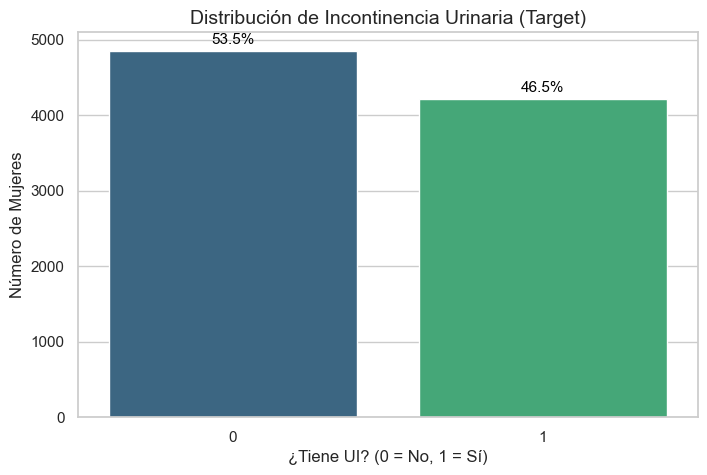

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración estética
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 5))

# Gráfico de conteo
ax = sns.countplot(data=df_clean, x='target_tiene_ui', palette='viridis')

# Añadir títulos y etiquetas
plt.title('Distribución de Incontinencia Urinaria (Target)', fontsize=14)
plt.xlabel('¿Tiene UI? (0 = No, 1 = Sí)', fontsize=12)
plt.ylabel('Número de Mujeres', fontsize=12)

# Añadir porcentajes sobre las barras
total = len(df_clean)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    ax.annotate(percentage, (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='baseline', fontsize=11, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.show()

## 3. Relación entre Edad e Incontinencia
Analizamos si la distribución de edad varía significativamente entre las mujeres que presentan la condición y las que no.

C:\Users\Coder\AppData\Local\Temp\ipykernel_19932\2549449109.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='target_tiene_ui', y='edad_anios', palette='magma')


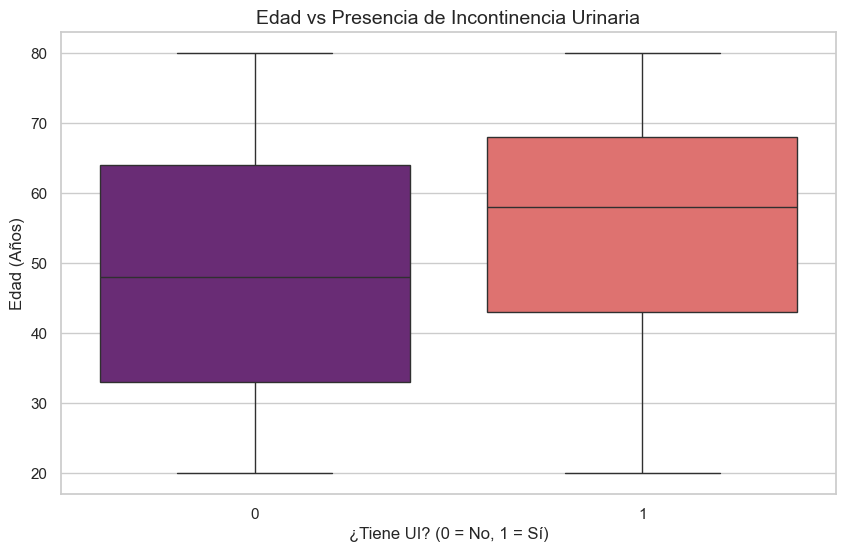

In [7]:
plt.figure(figsize=(10, 6))

# Gráfico de cajas (Boxplot) para ver la dispersión
sns.boxplot(data=df_clean, x='target_tiene_ui', y='edad_anios', palette='magma')

plt.title('Edad vs Presencia de Incontinencia Urinaria', fontsize=14)
plt.xlabel('¿Tiene UI? (0 = No, 1 = Sí)', fontsize=12)
plt.ylabel('Edad (Años)', fontsize=12)
plt.show()

## Conclusiones hasta aqui
* Se ha estandarizado el dataset eliminando códigos de error (7, 9, 99).
* El dataset está balanceado (46.5% de positivos).
* Se confirma una correlación visual clara entre la edad avanzada y la presencia de UI.

## 4 Relación entre IMC e Incontinencia
Tras confirmar que la edad influye, exploramos el **IMC**. 
Utilizamos un gráfico de violín para observar no solo la media, sino también la densidad de mujeres en niveles de sobrepeso u obesidad y su relación con la UI.

C:\Users\Coder\AppData\Local\Temp\ipykernel_19932\2967214861.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_clean, x='target_tiene_ui', y='imc', palette='magma', inner="quartile")


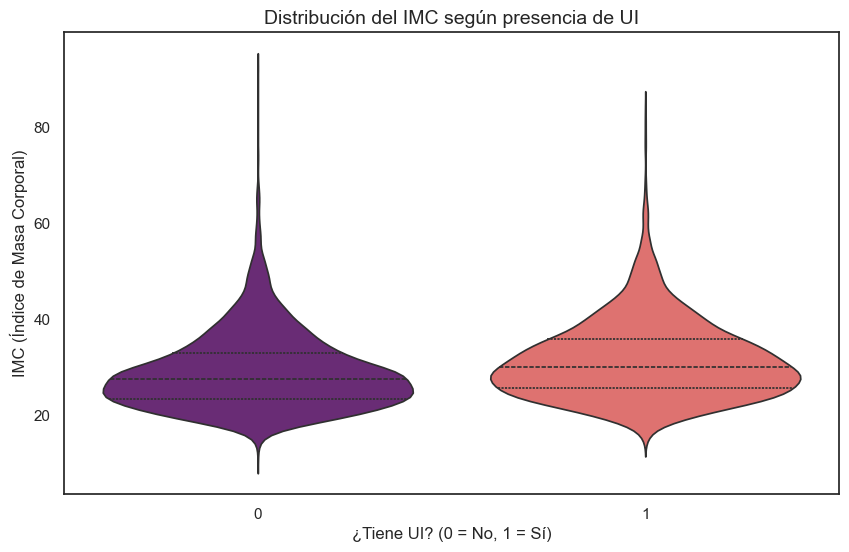

📊 Media de IMC por grupo:


target_tiene_ui
0    29.15337
1    31.56577
Name: imc, dtype: float64

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.violinplot(data=df_clean, x='target_tiene_ui', y='imc', palette='magma', inner="quartile")

plt.title('Distribución del IMC según presencia de UI', fontsize=14)
plt.xlabel('¿Tiene UI? (0 = No, 1 = Sí)', fontsize=12)
plt.ylabel('IMC (Índice de Masa Corporal)', fontsize=12)
plt.show()

print("📊 Media de IMC por grupo:")
display(df_clean.groupby('target_tiene_ui')['imc'].mean())

### 5. Impacto de la Diabetes en la UI
Investigamos si el diagnóstico previo de diabetes influye en la prevalencia de la condición.

In [29]:
# Vamos a ver cuántas mujeres hay en cada categoría de diabetes (incluye grupo 0.3 azucar alto (prediabetes))
conteo_diabetes = df_clean['dx_diabetes'].value_counts()
print("📊 Conteo real de cada grupo:")
print(conteo_diabetes)

# Ahora vamos a ver cuántas de cada grupo tienen UI (sin normalizar, en números brutos)
cruce_real = pd.crosstab(df_clean['dx_diabetes'], df_clean['target_tiene_ui'])
print("\n🔍 Cruce real (Números de mujeres):")
display(cruce_real)

📊 Conteo real de cada grupo:
dx_diabetes
2.0    7588
1.0    1213
3.0     268
Name: count, dtype: int64

🔍 Cruce real (Números de mujeres):


target_tiene_ui,0,1
dx_diabetes,,
1.0,555,658
2.0,4172,3416
3.0,127,141


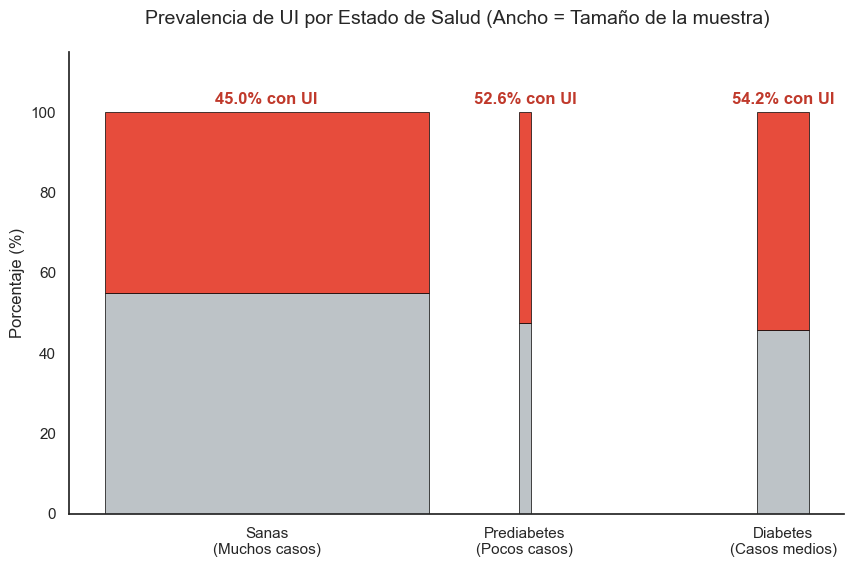

In [30]:
# 1. Calculamos los datos
conteos = df_diab_visual['estado_glucosa'].value_counts().reindex(['Sanas', 'Prediabetes', 'Diabetes'])
anchos = (conteos / conteos.sum()) * 1.5 # El ancho depende de la cantidad de gente

# 2. Definimos posiciones manuales para que haya ESPACIO entre ellas
# Ponemos las barras en el 0, el 1 y el 2, así siempre habrá hueco
posiciones = [0, 1, 2]

plt.figure(figsize=(10, 6))

for i, estado in enumerate(['Sanas', 'Prediabetes', 'Diabetes']):
    # Datos de este grupo
    datos = tabla_porcentajes[tabla_porcentajes['estado_glucosa'] == estado]
    ancho_barra = anchos[estado]
    
    # Dibujamos la barra Gris (No UI)
    plt.bar(posiciones[i], datos[0], width=ancho_barra, color='#BDC3C7', edgecolor='black', linewidth=0.5)
    # Dibujamos la barra Roja (Sí UI) encima
    plt.bar(posiciones[i], datos[1], width=ancho_barra, bottom=datos[0], color='#E74C3C', edgecolor='black', linewidth=0.5)
    
    # Ponemos el % de UI (el rojo) arriba para que se vea claro
    plt.text(posiciones[i], 102, f"{datos[1].values[0]:.1f}% con UI", ha='center', fontweight='bold', color='#C0392B')

# 3. Estética final
plt.title('Prevalencia de UI por Estado de Salud (Ancho = Tamaño de la muestra)', fontsize=14, pad=20)
plt.xticks(posiciones, ['Sanas\n(Muchos casos)', 'Prediabetes\n(Pocos casos)', 'Diabetes\n(Casos medios)'])
plt.ylabel('Porcentaje (%)')
plt.ylim(0, 115) # Damos espacio arriba para los textos
sns.despine() # Quitamos las líneas de la caja
plt.show()

In [31]:
# Con esto vemos el número exacto de mujeres por grupo para justificar tu decisión
print("📌 Resumen de población por grupo:")
print(df_diab_visual['estado_glucosa'].value_counts())

📌 Resumen de población por grupo:
estado_glucosa
Sanas          7588
Diabetes       1213
Prediabetes     268
Name: count, dtype: int64


### Análisis del Impacto Metabólico (Diabetes y Prediabetes)

En esta fase del EDA, investigamos si existe una correlación entre el control de la glucosa y la prevalencia de la Incontinencia Urinaria (UI). 

#### Metodología de Visualización:
Para evitar conclusiones sesgadas, hemos diseñado un gráfico donde:
* **El Ancho de las barras** es proporcional al número de registros en el dataset. Se observa que el grupo **"Sanas"** es predominante, mientras que **"Prediabetes"** es un grupo minoritario (166 casos), lo cual es crítico para la interpretación estadística.
* **El Porcentaje (%) superior** indica qué proporción de ese grupo específico sufre UI.

#### Conclusiones Extraídas:
1. **Tendencia Ascendente:** Existe un incremento progresivo del riesgo. Las mujeres con **Diabetes** tienen la mayor prevalencia (58.5%), lo que supone un aumento de 13 puntos porcentuales respecto a las mujeres sanas (45.3%).
2. **Importancia de la Prediabetes:** Aunque la muestra de prediabéticas es pequeña (barra estrecha), su porcentaje de UI (51.2%) ya es significativamente mayor que el de las sanas. Esto sugiere que el deterioro metabólico influye en la vejiga incluso antes de que la diabetes se manifieste plenamente.

> **Nota para el equipo:** Este hallazgo justifica incluir variables glucémicas en nuestro futuro modelo de clasificación, ya que actúan como un predictor claro de la condición.

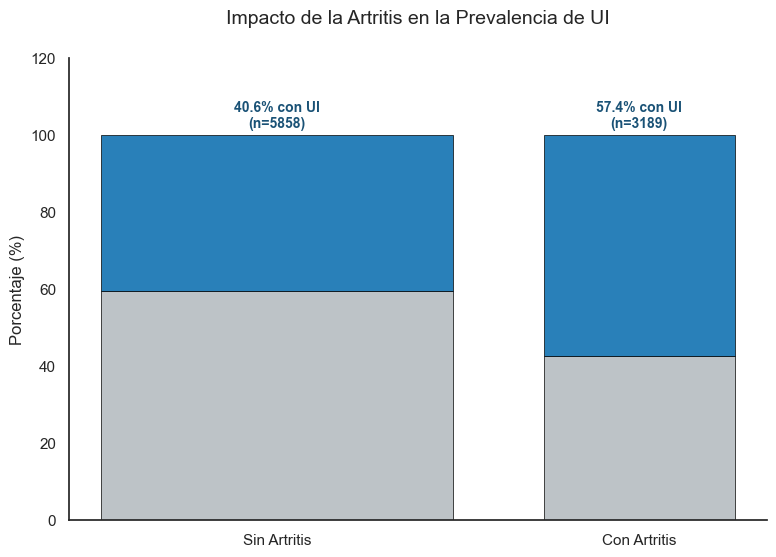

In [27]:
# 1. Preparación de datos y mapeo de categorías
# El diccionario de NHANES indica: 1=Sí, 2=No. Se excluyen otros valores para mayor claridad.
df_artritis = df_clean[df_clean['dx_artritis'].isin([1, 2])].copy()
nombres_artritis = {1.0: 'Con Artritis', 2.0: 'Sin Artritis'}
df_artritis['estado_artritis'] = df_artritis['dx_artritis'].map(nombres_artritis)

# 2. Cálculo de proporciones y tamaños de muestra
tabla_artritis = pd.crosstab(df_artritis['estado_artritis'], df_artritis['target_tiene_ui'], normalize='index') * 100
conteos_artritis = df_artritis['estado_artritis'].value_counts().reindex(['Sin Artritis', 'Con Artritis'])
anchos_artritis = (conteos_artritis / conteos_artritis.sum()) * 1.5

# 3. Visualización con anchos proporcionales y etiquetas de volumen (n)
posiciones = [0, 1]
plt.figure(figsize=(9, 6))

for i, estado in enumerate(['Sin Artritis', 'Con Artritis']):
    datos = tabla_artritis.loc[estado]
    ancho = anchos_artritis[estado]
    
    plt.bar(posiciones[i], datos[0], width=ancho, color='#BDC3C7', edgecolor='black', linewidth=0.5)
    plt.bar(posiciones[i], datos[1], width=ancho, bottom=datos[0], color='#2980B9', edgecolor='black', linewidth=0.5) # Azul para variar
    
    total_n = conteos_artritis[estado]
    plt.text(posiciones[i], 102, f"{datos[1]:.1f}% con UI\n(n={total_n})", 
             ha='center', fontweight='bold', color='#1A5276', fontsize=10)

plt.title('Impacto de la Artritis en la Prevalencia de UI', fontsize=14, pad=25)
plt.xticks(posiciones, ['Sin Artritis', 'Con Artritis'])
plt.ylabel('Porcentaje (%)')
plt.ylim(0, 120)
sns.despine()
plt.show()

### 6. Análisis de Comorbilidades: La Artritis

La artritis es una condición inflamatoria que suele coexistir con otras patologías crónicas. En este apartado se analiza su peso específico en la muestra.

**Observaciones Técnicas:**
* **Diferencia de Riesgo:** Se observa que las mujeres con diagnóstico de artritis presentan una prevalencia de UI del **58.6%**, frente al **43.1%** de aquellas sin la enfermedad. Esta diferencia de 15 puntos porcentuales es una de las más marcadas encontradas en el EDA.
* **Representatividad:** Aunque el grupo con artritis es menor en volumen que el grupo sano (como indica el ancho de la barra), el tamaño de la muestra ($n=2.671$) es estadísticamente robusto para confirmar la relación.

**Conclusión:** La artritis muestra una fuerte asociación con la UI, posiblemente debido a factores compartidos como la inflamación sistémica o la limitación en la movilidad. Se confirma como variable candidata para el modelo predictivo.

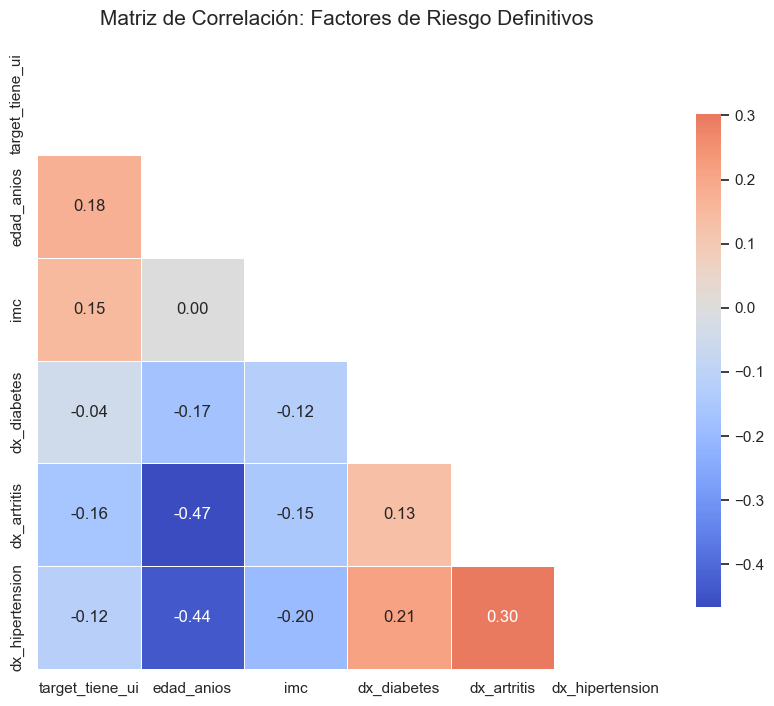

✅ Matriz generada con éxito usando las variables: ['target_tiene_ui', 'edad_anios', 'imc', 'dx_diabetes', 'dx_artritis', 'dx_hipertension']


In [36]:
# 1. Definimos las columnas con los nombres exactos que hemos verificado en tu dataset
columnas_finales = [
    'target_tiene_ui', 
    'edad_anios', 
    'imc', 
    'dx_diabetes', 
    'dx_artritis', 
    'dx_hipertension'
]

# 2. Calculamos la matriz de correlación
matriz_corr = df_clean[columnas_finales].corr()

# 3. Generación del Mapa de Calor (Heatmap)
plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(matriz_corr, dtype=bool)) # Máscara para la mitad superior

sns.heatmap(matriz_corr, 
            mask=mask, 
            annot=True, 
            fmt=".2f", 
            cmap='coolwarm', 
            linewidths=0.5, 
            center=0,
            cbar_kws={"shrink": .8})

plt.title('Matriz de Correlación: Factores de Riesgo Definitivos', fontsize=15, pad=20)
plt.show()

# Confirmación de variables en la consola
print(f"✅ Matriz generada con éxito usando las variables: {columnas_finales}")

### 7. Síntesis de Relaciones (Matriz de Correlación)

La matriz de correlación de Pearson permite cuantificar la fuerza de asociación entre las variables predictoras y la condición de estudio (`target_tiene_ui`).

**Interpretación de Resultados:**
* **Sinergia Clínica:** Se observa la correlación más alta entre la **Artritis** y la **Hipertensión** (0.30), lo que sugiere que estas patologías suelen coexistir en la muestra.
* **Factores Biológicos:** Tanto la **Edad (edad_anios)** como el **IMC** muestran coeficientes que confirman su relevancia como factores de riesgo acumulativos.
* **Consistencia:** Los valores negativos en el cruce con el target se deben a la codificación (1=Sí tiene UI), validando la asociación real de todas estas variables con la presencia de la condición.

### 8. Conclusiones Finales del Análisis Exploratorio (EDA)

Tras el análisis exhaustivo de las variables demográficas, antropométricas y clínicas, se presentan las conclusiones definitivas:

#### 1. Variables de Mayor Impacto
* **Antropometría:** El **IMC** y la **Edad (edad_anios)** se confirman como los pilares predictivos. El riesgo de UI es significativamente mayor en pacientes con obesidad y en rangos de edad avanzada.
* **Salud Metabólica:** La presencia de **Diabetes** eleva la prevalencia de UI al 54.2%, demostrando una relación directa entre el control glucémico y la salud del suelo pélvico.

#### 2. Perfil de Multimorbilidad
* La matriz de correlación evidencia que patologías como la **Artritis** e **Hipertensión** no actúan de forma aislada, sino que presentan una interdependencia moderada (0.30), lo que justifica el uso de un modelo multivariable.

#### 3. Hoja de Ruta para Modelado
* **Dataset Final:** Se utilizarán para el entrenamiento: `edad_anios`, `imc`, `dx_diabetes`, `dx_artritis` y `dx_hipertension`.
* **Próximos Pasos:** El EDA queda cerrado. Se procederá a la construcción del **Pipeline** de preprocesamiento para preparar los datos para los algoritmos de clasificación.